### **Mount to the Drive**

In [ ]:
base_dir = '/content/drive/MyDrive/epipolar-geometry-dinov2/epipolar-geometry-dinov2'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd $base_dir

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/epipolar-geometry-dinov2/epipolar-geometry-dinov2


In [ ]:
# Run the command below if you need
!pip install -q -r requirements.txt

In [ ]:
import cv2 as cv
from src.visualization import stereo_viewer, draw_epilines
from src.geometry import calculate_fundamental_matrix_from_pts
from src.feature_extraction import load_dinov2_model, extract_dinov2_features_stereo, match_dinov2_features

In [ ]:
processor, model, patch_size = load_dinov2_model()

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [ ]:
left_img_path = f'{base_dir}/data/kitti_sample/sequences/00/image_2/000000.png'
right_img_path = f'{base_dir}/data/kitti_sample/sequences/00/image_3/000000.png'

left_img = cv.imread(left_img_path)
right_img = cv.imread(right_img_path)

(resized_img_1, resized_img_2), normalized_patch_features, num_patches_width, num_patches_flat = extract_dinov2_features_stereo((left_img, right_img), processor, model, patch_size)

<class 'transformers.models.bit.image_processing_bit.BitImageProcessor'>
<class 'transformers.models.dinov2.modeling_dinov2.Dinov2Model'>
<class 'int'>


In [ ]:
left_pts, right_pts = match_dinov2_features(normalized_patch_features, patch_size, num_patches_width, num_patches_flat)
F, (left_pts_masked, right_pts_masked) = calculate_fundamental_matrix_from_pts(left_pts, right_pts)

# **Computing Epipolar Lines**

In [ ]:
lines_1 = cv.computeCorrespondEpilines(right_pts_masked, 2, F)
lines_2 = cv.computeCorrespondEpilines(left_pts_masked, 1, F)

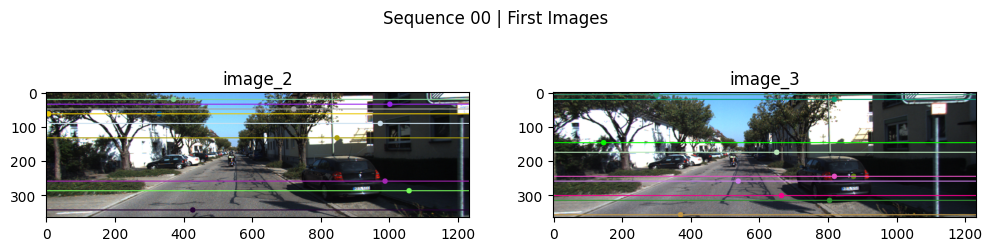

In [ ]:
left_img_with_lines = draw_epilines(resized_img_1.copy(), lines_1, left_pts_masked)
right_img_with_lines = draw_epilines(resized_img_2.copy(), lines_2, right_pts_masked)

stereo_viewer(left_img_with_lines, right_img_with_lines)